step One - Importing libraries

In [9]:
import os
import random


import numpy as np
import pandas as pd
import cv2

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)
import tensorflow as tf

from tensorflow.keras.models import Sequential, load_model

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Flatten,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)




print("Succesfully imported Libraries")

Succesfully imported Libraries


Step 2: Loading Images

In [10]:
PARA_DIR = "../data/raw/Parasitized"
UNINF_DIR = "../data/raw/Uninfected"

Pimages = os.listdir(PARA_DIR)
Uimages = os.listdir(UNINF_DIR)

print("Parasitized Images:", len(Pimages))
print("Uninfected Images:", len(Uimages))

Parasitized Images: 13780
Uninfected Images: 13780


Step 3: Checking sample images

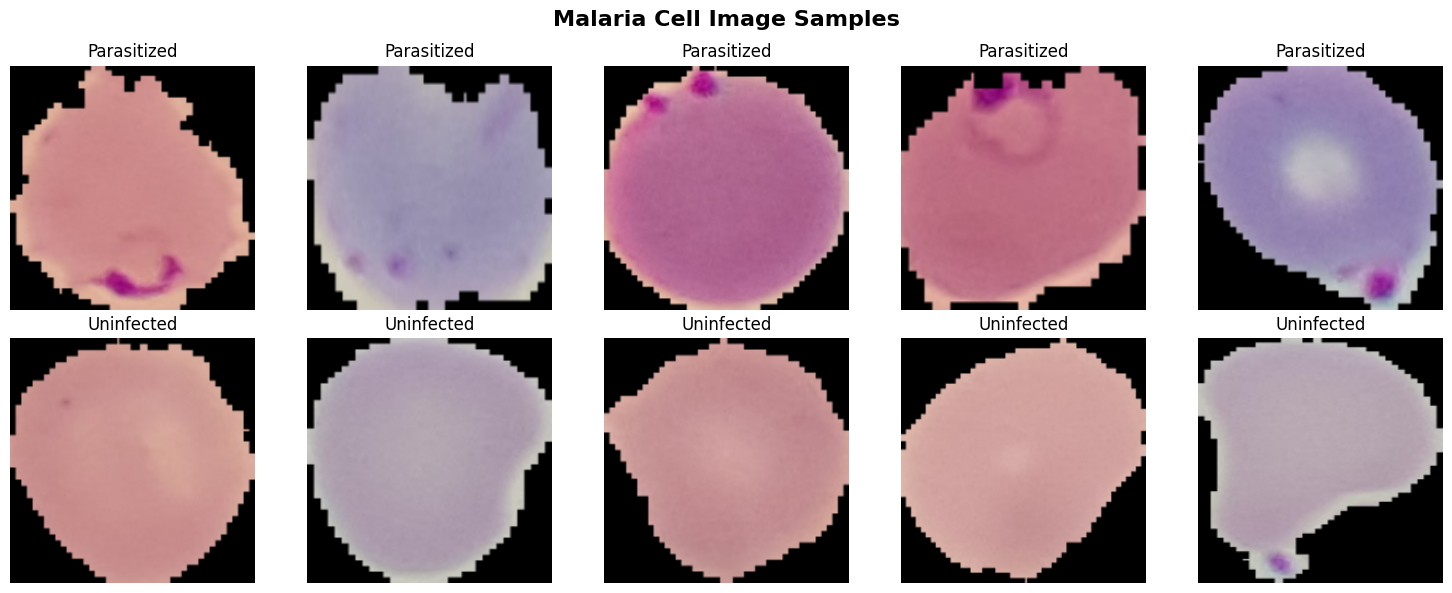

In [15]:
from pathlib import Path
import random
import cv2
import matplotlib.pyplot as plt



BASE_DIR = Path("../data/raw")

PARASITIZED_DIR = BASE_DIR / "Parasitized"
UNINFECTED_DIR = BASE_DIR / "Uninfected"

IMAGE_SIZE = (224, 224, )


def validate_directory(directory: Path) -> None:
    """
    Ensure dataset directory exists.

    Args:
        directory (Path): Directory path

    Raises:
        FileNotFoundError: If directory does not exist
    """

    if not directory.exists():
        raise FileNotFoundError(f"Directory not found: {directory}")


validate_directory(PARASITIZED_DIR)
validate_directory(UNINFECTED_DIR)



def load_image(image_path: Path):
    """
    Load and preprocess single image.

    Args:
        image_path (Path): Path to image file

    Returns:
        image (numpy.ndarray): RGB image
    """

    image = cv2.imread(str(image_path))

    if image is None:
        raise ValueError(f"Failed to load image: {image_path}")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    image = cv2.resize(image, IMAGE_SIZE)

    return image



def display_sample_images(
    parasitized_dir: Path,
    uninfected_dir: Path,
    samples_per_class: int = 5
):
    """
    Display sample malaria cell images.

    Args:
        parasitized_dir (Path): Infected image directory
        uninfected_dir (Path): Healthy image directory
        samples_per_class (int): Number of samples to display
    """

    parasitized_images = list(parasitized_dir.iterdir())
    uninfected_images = list(uninfected_dir.iterdir())

    sampled_parasitized = random.sample(
        parasitized_images,
        samples_per_class
    )

    sampled_uninfected = random.sample(
        uninfected_images,
        samples_per_class
    )

    fig, axes = plt.subplots(
        2,
        samples_per_class,
        figsize=(15, 6)
    )

    fig.suptitle(
        "Malaria Cell Image Samples",
        fontsize=16,
        fontweight="bold"
    )



    for idx, image_path in enumerate(sampled_parasitized):

        image = load_image(image_path)

        axes[0, idx].imshow(image)

        axes[0, idx].set_title("Parasitized")

        axes[0, idx].axis("off")



    for idx, image_path in enumerate(sampled_uninfected):

        image = load_image(image_path)

        axes[1, idx].imshow(image)

        axes[1, idx].set_title("Uninfected")

        axes[1, idx].axis("off")

    plt.tight_layout()

    plt.show()



display_sample_images(
    PARASITIZED_DIR,
    UNINFECTED_DIR,
    samples_per_class=5
)